In [18]:
from utils import *
import pandas as pd
import pairadigm as pdm
import dotenv

dotenv.load_dotenv(dotenv_path="C:/Users/mlchr/OneDrive/Professional/Data Science/Maryland/bechmark analysis pipeline/benchmark-analysis/.env")

True

In [7]:
data = last_full_pull(level='card')
data.head(5)

Loading most recent full pull file...
Loading file: ../Data/Full Pulls\ygo_full_daily_2026-05-22_21-36-38.csv
Data shape after filtering to oldest tcg_date per card_id: (13818, 57)


,card_id,name,desc,pend_desc,monster_desc,type,subtype,frame,race,archetype,...,price_range,price_stddev,is_tcg_exclusive,is_ocg_exclusive,days_since_tcg_release,days_since_ocg_release,first_market,market_delay,desc_length,tcg_date_dt
0,80181649,"""A Case for K9""","When this card is activated: You can add 1 ""K9...",NaN,NaN,Spell Card,Continuous Spell,spell,Continuous,K9,...,0.00,NaN,0,0,295.0,426.0,OCG,131.0,92,2025-07-31
2,34541863,"""A"" Cell Breeding Device","During each of your Standby Phases, put 1 A-Co...",NaN,NaN,Spell Card,Continuous Spell,spell,Continuous,Alien,...,24.25,11.990442,0,0,6946.0,7036.0,OCG,90.0,16,2007-05-16
3,64163367,"""A"" Cell Incubator",Each time an A-Counter(s) is removed from play...,NaN,NaN,Spell Card,Continuous Spell,spell,Continuous,Alien,...,1.02,0.477729,0,0,6764.0,6880.0,OCG,116.0,32,2007-11-14
4,91231901,"""A"" Cell Recombination Device",Target 1 face-up monster on the field; send 1 ...,NaN,NaN,Spell Card,Quick-Play Spell,spell,Quick-Play,Alien,...,0.81,0.334764,0,0,3487.0,3604.0,OCG,117.0,66,2016-11-03
5,73262676,"""A"" Cell Scatter Burst","Select 1 face-up ""Alien"" monster you control. ...",NaN,NaN,Spell Card,Quick-Play Spell,spell,Quick-Play,Alien,...,9.57,4.551417,0,0,7023.0,7127.0,OCG,104.0,22,2007-02-28


In [8]:
# Combine text-relevant columns into a single text field for analysis
for col in ['name', 'subtype', 'desc', 'race', 'attribute', 'level']:
    data[col] = data[col].fillna('').astype(str)

data['text'] = "Card Name: " + data['name'] + " | " + \
    " Card Type: " + data['subtype'] + " | " + \
        " Card Race: " + data['race'] + " | " + \
        " Card Level: " + data['level'].astype(str) + " | " + \
        " Card Attribute: " + data['attribute'] + " | " + \
        " Card Description: " + data['desc'] 

In [16]:
# Pull a random sample based on the numeric feature tcg_months_since_release
data['release_bin'] = pd.qcut(data['days_since_tcg_release'], q=20, duplicates='drop')

# Now perform stratified sampling based on these bins
# Pass observed=False to silence the first warning
# Explicitly drop the grouping column after sampling to silence the second warning
sample = (
    data.groupby('release_bin', group_keys=False, observed=False)
        .apply(lambda x: x.sample(n=50, random_state=42), include_groups=False)
        .reset_index(drop=True)
)

# Remove the 'release_bin' column as it's no longer needed
data = data.drop(columns=['release_bin'])
sample

,card_id,name,desc,pend_desc,monster_desc,type,subtype,frame,race,archetype,...,price_stddev,is_tcg_exclusive,is_ocg_exclusive,days_since_tcg_release,days_since_ocg_release,first_market,market_delay,desc_length,tcg_date_dt,text
0,42781164,Kewl Tune Track Maker,"1 ""Kewl Tune"" Tuner + 1+ Tuners\r\nIf this car...",NaN,NaN,Synchro Tuner Monster,Synchro Tuner Effect Monster,synchro,Machine,Kewl Tune,...,NaN,0,0,169.0,272.0,OCG,103.0,91,2025-12-04,Card Name: Kewl Tune Track Maker | Card Type:...
1,17832359,"Wonko, Noble Knight of the Forest",If this card is Normal or Special Summoned: Yo...,NaN,NaN,Effect Monster,Effect Monster,effect,Beast,Noble Knight,...,NaN,0,0,343.0,517.0,OCG,174.0,95,2025-06-13,"Card Name: Wonko, Noble Knight of the Forest |..."
2,44694191,Fleeting Phantom Mask Master,"If this card battles a monster, neither can be...",NaN,NaN,Effect Monster,Effect Monster,effect,Illusion,NaN,...,NaN,0,0,15.0,118.0,OCG,103.0,92,2026-05-07,Card Name: Fleeting Phantom Mask Master | Car...
3,39520293,Junk Mail,A Synchro Monster that used this card as mater...,NaN,NaN,Tuner Monster,Tuner Effect Monster,effect,Warrior,Junk,...,NaN,0,0,92.0,974.0,OCG,882.0,69,2026-02-19,Card Name: Junk Mail | Card Type: Tuner Effec...
4,33995387,Hero's Rule 1: Five Freedoms,Target up to 5 cards in any GY(s); banish them...,NaN,NaN,Trap Card,Normal Trap,trap,Normal,Rose,...,NaN,0,0,92.0,251.0,OCG,159.0,59,2026-02-19,Card Name: Hero's Rule 1: Five Freedoms | Car...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,40240595,Cocoon of Evolution,"You can target 1 ""Petit Moth"" you control; equ...",NaN,NaN,Effect Monster,Effect Monster,effect,Insect,NaN,...,0.368273,0,0,8731.0,9801.0,OCG,1070.0,36,2002-06-26,Card Name: Cocoon of Evolution | Card Type: E...
996,1641882,Fusionist,"""Petit Angel"" + ""Mystical Sheep #2""",NaN,NaN,Fusion Monster,Fusion Monster,fusion,Beast,NaN,...,0.317753,0,0,8841.0,9939.0,OCG,1098.0,6,2002-03-08,Card Name: Fusionist | Card Type: Fusion Mons...
997,81386177,Bottom Dweller,This is one sea creature whose wrath is someth...,NaN,NaN,Normal Monster,Normal Monster,normal,Fish,NaN,...,0.435536,0,0,8731.0,9801.0,OCG,1070.0,13,2002-06-26,Card Name: Bottom Dweller | Card Type: Normal...
998,10992251,Gradius,A high-performance jet fighter with power caps...,NaN,NaN,Normal Monster,Normal Monster,normal,Machine,NaN,...,0.503877,0,0,8615.0,9290.0,OCG,675.0,11,2002-10-20,Card Name: Gradius | Card Type: Normal Monste...


## Utility

In [20]:
# Load the CGCoT prompts from ../Data/cgcot prompts/utility_prompts.txt
with open('../Data/cgcot prompts/utility_prompts.txt', 'r') as file:
    prompts = file.readlines()

In [19]:
help(pdm.Pairadigm)

Help on class Pairadigm in module pairadigm.core:

class Pairadigm(builtins.object)
 |  Pairadigm(data: 'pd.DataFrame', item_id_name: 'Optional[str]' = None, text_name: 'Optional[str]' = None, paired: 'bool' = False, item_id_cols: 'Optional[List[str]]' = None, item_text_cols: 'Optional[List[str]]' = None, annotated: 'bool' = False, annotator_cols: 'Optional[List[str]]' = None, llm_annotator_cols: 'Optional[List[str]]' = None, prior_breakdown_cols: 'Optional[List[str]]' = None, cgcot_prompts: 'Optional[List[str]]' = None, model_name: 'Optional[Union[str, List[str]]]' = 'gemini-2.0-flash-exp', api_key: 'Optional[Union[str, List[str]]]' = None, base_url: 'Optional[Union[str, List[str]]]' = None, target_concept: 'Optional[str]' = None, llm_clients: 'Optional[Union[LLMClient, List[LLMClient]]]' = None, save_dir: 'Optional[str]' = None)
 |  
 |      Main class for Concept-Guided Chain-of-Thought (CGCoT) pairwise annotation.
 |  
 |      ``Pairadigm`` orchestrates the full pipeline for measur

In [32]:
p = pdm.Pairadigm(
    data=sample,
    item_id_name='card_id',
    text_name='text',
    cgcot_prompts=prompts,
    model_name='gemini-3.1-flash-lite',
    api_key=os.getenv('GEMINI_API_KEY'),
    target_concept='utility in Yu-Gi-Oh!',
    save_dir='../Results/pairadigms/'
)

In [33]:
p.test_clients_connection(return_responses=True)

Testing LLM client connections using: 'What is the best restaurant in Detroit, MI?'...


  gemini-3.1-flash-lite: MODEL OK


{'gemini-3.1-flash-lite': 'Determining the premier dining establishment in Detroit, MI, requires evaluating top-rated venues like Selden Standard, known for its seasonal small plates and refined atmosphere.'}

In [27]:
p.estimate_costs(
    custom_cost_per_1m_input=0.25,
    custom_cost_per_1m_output=1.50
)


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gemini-3.1-flash-lite
Pricing used: $0.250 per 1M input | $1.500 per 1M output
  [Breakdowns] Items: 1000, Expected Input: ~1,340,677, Expected Output: ~1,400,000
  >>> Estimated Cost: $2.4352
------------------------------------------------------------


In [34]:
p.generate_breakdowns()


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gemini-3.1-flash-lite
Pricing used: Unknown or $0 per 1M tokens
  [Breakdowns] Items: 1000, Expected Input: ~1,340,677, Expected Output: ~1,400,000
  >>> Estimated Cost: $0.0000
------------------------------------------------------------

Generating breakdowns for 1000 items using: gemini-3.1-flash-lite


[gemini-3.1-flash-lite]: 100%|██████████| 1000/1000 [00:13<00:00, 73.43it/s, success=0, failed=1000]

Completed: 0/1000 items
Failed: 1000 items

Breakdowns added to [object].data — column(s): CGCoT_Breakdown
Pairadigm saved to: ..\Results\pairadigms/
  Files written: metadata.json, data.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: ..\Results\pairadigms


In [30]:
p.generate_pairings(breakdowns=True, num_pairs_per_item=20)

Pairwise DataFrame with breakdowns created and stored in self.pairwise_df


,item1,item2,breakdown1,breakdown2
0,92080692,37953640,Original Text: Card Name: Showdown of the Secr...,Original Text: Card Name: Royal Swamp Eel | C...
1,21970285,70231910,Original Text: Card Name: Dragon Horn Hunter |...,Original Text: Card Name: Dark Core | Card Ty...
2,44822037,24573625,Original Text: Card Name: Angel Statue - Azuru...,Original Text: Card Name: Deskbot 008 | Card ...
3,7628844,69164989,Original Text: Card Name: Number C32: Shark Dr...,Original Text: Card Name: Rikka Glamour | Car...
4,27345070,67598234,Original Text: Card Name: Vanquish Soul - Cont...,"Original Text: Card Name: Gaia Saber, the Ligh..."
...,...,...,...,...
2221,70298454,92080692,Original Text: Card Name: Leng Ling | Card Ty...,Original Text: Card Name: Showdown of the Secr...
2222,23571046,2851070,Original Text: Card Name: Quillbolt Hedgehog |...,Original Text: Card Name: Reflect Bounder | C...
2223,97631303,43586926,Original Text: Card Name: Magicians' Souls | ...,Original Text: Card Name: Twin-Headed Behemoth...
2224,3966653,61679541,Original Text: Card Name: Flower Cardian Board...,Original Text: Card Name: Battlin' Boxer Rabbi...


In [31]:
p.generate_pairwise_annotations()

[default] Completed 50/2226 comparisons
[default] Completed 100/2226 comparisons
[default] Completed 150/2226 comparisons
[default] Completed 200/2226 comparisons
[default] Completed 250/2226 comparisons
[default] Completed 300/2226 comparisons
[default] Completed 350/2226 comparisons
[default] Completed 400/2226 comparisons
[default] Completed 450/2226 comparisons
[default] Completed 500/2226 comparisons
[default] Completed 550/2226 comparisons
[default] Completed 600/2226 comparisons
[default] Completed 650/2226 comparisons
[default] Completed 700/2226 comparisons
[default] Completed 750/2226 comparisons
[default] Completed 800/2226 comparisons
[default] Completed 850/2226 comparisons
[default] Completed 900/2226 comparisons
[default] Completed 950/2226 comparisons
[default] Completed 1000/2226 comparisons
[default] Completed 1050/2226 comparisons
[default] Completed 1100/2226 comparisons
[default] Completed 1150/2226 comparisons
[default] Completed 1200/2226 comparisons
[default] Co

,item1,item2,breakdown1,breakdown2,decision,justification
0,92080692,37953640,Original Text: Card Name: Showdown of the Secr...,Original Text: Card Name: Royal Swamp Eel | C...,Text2,FINAL ANSWER: Description 2 \nJUSTIFICATION: ...
1,21970285,70231910,Original Text: Card Name: Dragon Horn Hunter |...,Original Text: Card Name: Dark Core | Card Ty...,Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...
2,44822037,24573625,Original Text: Card Name: Angel Statue - Azuru...,Original Text: Card Name: Deskbot 008 | Card ...,Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...
3,7628844,69164989,Original Text: Card Name: Number C32: Shark Dr...,Original Text: Card Name: Rikka Glamour | Car...,Text2,FINAL ANSWER: Description 2 \nJUSTIFICATION: ...
4,27345070,67598234,Original Text: Card Name: Vanquish Soul - Cont...,"Original Text: Card Name: Gaia Saber, the Ligh...",Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...
...,...,...,...,...,...,...
2221,70298454,92080692,Original Text: Card Name: Leng Ling | Card Ty...,Original Text: Card Name: Showdown of the Secr...,Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...
2222,23571046,2851070,Original Text: Card Name: Quillbolt Hedgehog |...,Original Text: Card Name: Reflect Bounder | C...,Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...
2223,97631303,43586926,Original Text: Card Name: Magicians' Souls | ...,Original Text: Card Name: Twin-Headed Behemoth...,Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...
2224,3966653,61679541,Original Text: Card Name: Flower Cardian Board...,Original Text: Card Name: Battlin' Boxer Rabbi...,Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...


In [15]:
p.score_items()

[default] Bradley-Terry model fitted with 2746 comparisons
[default] Mean starter card in Yu-Gi-Oh! score: 0.589
[default] Std starter card in Yu-Gi-Oh! score: 0.209
Score range: 0.000 to 1.000
25th percentile: 0.429
50th percentile (median): 0.596
75th percentile: 0.751

Highest scoring item on starter card in Yu-Gi-Oh! (score: 1.000):
Card Name: Dogmatika Ecclesia, the Virtuous |  Card Type: Effect Monster |  Card Race: Spellcaster |  Card Level: 4.0 |  Card Attribute: LIGHT |  Card Description: Cannot be destroyed by battle with a monster Special Summoned from the Extra Deck. You can only use each of the following effects of "Dogmatika Ecclesia, the Virtuous" once per turn. If a monster Special Summoned from the Extra Deck is on the field: You can Special Summon this card from your hand. If this card is Normal or Special Summoned: You can activate this effect; add 1 "Dogmatika" card from your Deck to your hand, except "Dogmatika Ecclesia, the Virtuous", also you cannot Special Summo

,card_id,name,desc,pend_desc,monster_desc,type,subtype,frame,race,archetype,...,is_ocg_exclusive,days_since_tcg_release,days_since_ocg_release,first_market,market_delay,desc_length,tcg_date_dt,text,CGCoT_Breakdown,Bradley_Terry_Score
0,24079759,Goblin Biker Dugg Charger,If this card is in your hand: You can detach 1...,NaN,NaN,Effect Monster,Effect Monster,effect,Warrior,Goblin,...,0,667.0,770.0,OCG,103.0,62,2024-02-08,Card Name: Goblin Biker Dugg Charger | Card T...,Original Text: Card Name: Goblin Biker Dugg Ch...,0.705371
1,27480536,Armored Shark,"(This card is always treated as an ""Armored Xy...",NaN,NaN,Effect Monster,Effect Monster,effect,Fish,Xyz,...,0,497.0,422.0,TCG,75.0,94,2024-07-27,Card Name: Armored Shark | Card Type: Effect ...,Original Text: Card Name: Armored Shark | Car...,0.730369
2,7628844,Number C32: Shark Drake LeVeiss,4 Level 5 monsters\r\nYou can also Xyz Summon ...,NaN,NaN,XYZ Monster,Xyz Effect Monster,xyz,Sea Serpent,Number,...,0,497.0,422.0,TCG,75.0,92,2024-07-27,Card Name: Number C32: Shark Drake LeVeiss | ...,Original Text: Card Name: Number C32: Shark Dr...,0.274477
3,47028805,L Magi Mergy,Gains ATK equal to the total Link Rating of th...,NaN,NaN,Effect Monster,Effect Monster,effect,Cyberse,NaN,...,0,497.0,422.0,TCG,75.0,57,2024-07-27,Card Name: L Magi Mergy | Card Type: Effect M...,Original Text: Card Name: L Magi Mergy | Card...,0.821519
4,98696958,Dark Corridor,"Add 1 ""Dark World"" monster from your Deck to y...",NaN,NaN,Spell Card,Normal Spell,spell,Normal,NaN,...,0,863.0,959.0,OCG,96.0,24,2023-07-27,Card Name: Dark Corridor | Card Type: Normal ...,Original Text: Card Name: Dark Corridor | Car...,0.942591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,27671321,Lightning Conger,This massive eel generates huge charges of ele...,NaN,NaN,Normal Monster,Normal Monster,normal,Thunder,NaN,...,0,8316.0,8904.0,OCG,588.0,13,2003-03-01,Card Name: Lightning Conger | Card Type: Norm...,Original Text: Card Name: Lightning Conger | ...,0.489546
396,53153481,Armaill,A strange warrior who manipulates three deadly...,NaN,NaN,Normal Monster,Normal Monster,normal,Warrior,NaN,...,0,8674.0,9751.0,OCG,1077.0,14,2002-03-08,Card Name: Armaill | Card Type: Normal Monste...,Original Text: Card Name: Armaill | Card Type...,0.460376
397,19230408,Offerings to the Doomed,Target 1 face-up monster on the field; destroy...,NaN,NaN,Spell Card,Quick-Play Spell,spell,Quick-Play,NaN,...,0,8316.0,8997.0,OCG,681.0,16,2003-03-01,Card Name: Offerings to the Doomed | Card Typ...,Original Text: Card Name: Offerings to the Doo...,0.342916
398,5758500,Soul Release,Target up to 5 cards in any GY(s); banish them.,NaN,NaN,Spell Card,Normal Spell,spell,Normal,NaN,...,0,8564.0,9571.0,OCG,1007.0,10,2002-06-26,Card Name: Soul Release | Card Type: Normal S...,Original Text: Card Name: Soul Release | Card...,0.263342


In [10]:
p.check_transitivity()

{'decision': (0.9941176470588236, 2, 340)}

In [38]:
help(RewardModel)

Help on class RewardModel in module pairadigm.model:

class RewardModel(builtins.object)
 |  RewardModel(
 |      model_name: str = 'answerdotai/ModernBERT-large',
 |      dropout: float = 0.1,
 |      max_length: int = 384,
 |      device: Optional[str] = None
 |  )
 |
 |  Unified class for training and using a reward model for text scoring.
 |
 |  This class handles:
 |  - Model initialization and configuration
 |  - Dataset creation and management
 |  - Training loop with pairwise comparisons
 |  - Scoring individual texts or batches
 |  - Score normalization
 |
 |  Methods defined here:
 |
 |  __init__(
 |      self,
 |      model_name: str = 'answerdotai/ModernBERT-large',
 |      dropout: float = 0.1,
 |      max_length: int = 384,
 |      device: Optional[str] = None
 |  )
 |      Initialize the reward model trainer.
 |
 |      Args:
 |          model_name: HuggingFace model identifier
 |          dropout: Dropout rate for reward head
 |          max_length: Maximum sequence len

# Train Model

In [55]:
#p.pairwise_df
p.scored_df

,card_id,name,desc,pend_desc,monster_desc,type,subtype,frame,race,archetype,...,is_ocg_exclusive,days_since_tcg_release,days_since_ocg_release,first_market,market_delay,desc_length,tcg_date_dt,text,CGCoT_Breakdown,Bradley_Terry_Score
0,24079759,Goblin Biker Dugg Charger,If this card is in your hand: You can detach 1...,NaN,NaN,Effect Monster,Effect Monster,effect,Warrior,Goblin,...,0,667.0,770.0,OCG,103.0,62,2024-02-08,Card Name: Goblin Biker Dugg Charger | Card T...,Original Text: Card Name: Goblin Biker Dugg Ch...,0.895993
1,27480536,Armored Shark,"(This card is always treated as an ""Armored Xy...",NaN,NaN,Effect Monster,Effect Monster,effect,Fish,Xyz,...,0,497.0,422.0,TCG,75.0,94,2024-07-27,Card Name: Armored Shark | Card Type: Effect ...,Original Text: Card Name: Armored Shark | Car...,0.875133
2,7628844,Number C32: Shark Drake LeVeiss,4 Level 5 monsters\r\nYou can also Xyz Summon ...,NaN,NaN,XYZ Monster,Xyz Effect Monster,xyz,Sea Serpent,Number,...,0,497.0,422.0,TCG,75.0,92,2024-07-27,Card Name: Number C32: Shark Drake LeVeiss | ...,Original Text: Card Name: Number C32: Shark Dr...,0.502703
3,47028805,L Magi Mergy,Gains ATK equal to the total Link Rating of th...,NaN,NaN,Effect Monster,Effect Monster,effect,Cyberse,NaN,...,0,497.0,422.0,TCG,75.0,57,2024-07-27,Card Name: L Magi Mergy | Card Type: Effect M...,Original Text: Card Name: L Magi Mergy | Card...,0.767215
4,98696958,Dark Corridor,"Add 1 ""Dark World"" monster from your Deck to y...",NaN,NaN,Spell Card,Normal Spell,spell,Normal,NaN,...,0,863.0,959.0,OCG,96.0,24,2023-07-27,Card Name: Dark Corridor | Card Type: Normal ...,Original Text: Card Name: Dark Corridor | Car...,0.949697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,4042268,Island Turtle,A huge turtle that is often mistaken for an is...,NaN,NaN,Normal Monster,Normal Monster,normal,Aqua,NaN,...,0,8448.0,9123.0,OCG,675.0,10,2002-10-20,Card Name: Island Turtle | Card Type: Normal ...,Original Text: Card Name: Island Turtle | Car...,0.132562
196,57281778,Ryu Kokki,"At the end of the Damage Step, if this card ba...",NaN,NaN,Effect Monster,Effect Monster,effect,Zombie,NaN,...,0,7950.0,8178.0,OCG,228.0,19,2004-03-01,Card Name: Ryu Kokki | Card Type: Effect Mons...,Original Text: Card Name: Ryu Kokki | Card Ty...,0.341181
197,50005633,Swordstalker,A monster formed by the vengeful souls of thos...,NaN,NaN,Normal Monster,Normal Monster,normal,Warrior,NaN,...,0,8653.0,9487.0,OCG,834.0,14,2002-03-29,Card Name: Swordstalker | Card Type: Normal M...,Original Text: Card Name: Swordstalker | Card...,0.067750
198,70231910,Dark Core,"Discard 1 card, then target 1 face-up monster ...",NaN,NaN,Spell Card,Normal Spell,spell,Normal,NaN,...,0,8093.0,8542.0,OCG,449.0,14,2003-10-10,Card Name: Dark Core | Card Type: Normal Spel...,Original Text: Card Name: Dark Core | Card Ty...,0.351263


In [9]:
prepped_data = pd.merge(
    p.pairwise_df[['item1', 'item2', 'breakdown1', 'breakdown2', 'decision']],
    p.scored_df[['card_id', 'Bradley_Terry_Score']],
    left_on='item1',
    right_on='card_id',
    how='left'
).rename(columns={'Bradley_Terry_Score': 'item_A_score'}).drop(columns=['card_id']).merge(
    p.scored_df[['card_id', 'Bradley_Terry_Score']],
    left_on='item2',
    right_on='card_id',
    how='left'
).rename(columns={'Bradley_Terry_Score': 'item_B_score'}).drop(columns=['card_id'])

prepped_data['margin'] = prepped_data['item_B_score'] - prepped_data['item_A_score']
prepped_data

,item1,item2,breakdown1,breakdown2,decision,item_A_score,item_B_score,margin
0,17871506,6631034,Original Text: Card Name: Meteor Dragon Red-Ey...,Original Text: Card Name: Frostosaurus | Card...,Text1,0.819501,0.369738,-0.449763
1,16024176,4042268,Original Text: Card Name: Flower Cardian Pine ...,Original Text: Card Name: Island Turtle | Car...,Text1,0.649560,0.378005,-0.271555
2,55888045,84653834,Original Text: Card Name: Number C106: Giant R...,Original Text: Card Name: ESP Amplifier | Car...,Text2,0.349030,0.428993,0.079964
3,58116537,5758500,Original Text: Card Name: Ancient Warriors Sag...,Original Text: Card Name: Soul Release | Card...,Text1,0.490162,0.263342,-0.226820
4,60303688,4042268,"Original Text: Card Name: Dogmatika Ecclesia, ...",Original Text: Card Name: Island Turtle | Car...,Text1,1.000000,0.378005,-0.621995
...,...,...,...,...,...,...,...,...
2741,77449773,8414337,Original Text: Card Name: Cynet Crosswipe | C...,Original Text: Card Name: Dust Storm of Gusto ...,Text1,0.543071,0.429611,-0.113460
2742,65646587,88204302,Original Text: Card Name: Pendulum Fusion | C...,Original Text: Card Name: Speed Recovery | Ca...,Text1,0.603704,0.671302,0.067598
2743,65646587,25165047,Original Text: Card Name: Pendulum Fusion | C...,Original Text: Card Name: Life Stream Dragon |...,Text1,0.603704,0.406595,-0.197110
2744,59069885,38180759,Original Text: Card Name: Embrace of the Tisti...,Original Text: Card Name: Unformed Void | Car...,Text1,0.596589,0.374741,-0.221848


In [ ]:
# p.save('../Results/starter_pairadigm.pkl')
# prepped_data.to_csv('../Results/starter_pairadigm_prepped_data.csv', index=False)


Pairadigm object saved successfully to: ../Results/starter_pairadigm.pkl


In [4]:
prepped_data = pd.read_csv('../Results/starter_pairadigm_prepped_data.csv')
p = load_pairadigm('../Results/starter_pairadigm.pkl')
p.data

Pairadigm object loaded successfully from: ../Results/starter_pairadigm.pkl


,card_id,name,desc,pend_desc,monster_desc,type,subtype,frame,race,archetype,...,is_tcg_exclusive,is_ocg_exclusive,days_since_tcg_release,days_since_ocg_release,first_market,market_delay,desc_length,tcg_date_dt,text,CGCoT_Breakdown
0,24079759,Goblin Biker Dugg Charger,If this card is in your hand: You can detach 1...,NaN,NaN,Effect Monster,Effect Monster,effect,Warrior,Goblin,...,0,0,667.0,770.0,OCG,103.0,62,2024-02-08,Card Name: Goblin Biker Dugg Charger | Card T...,Original Text: Card Name: Goblin Biker Dugg Ch...
1,27480536,Armored Shark,"(This card is always treated as an ""Armored Xy...",NaN,NaN,Effect Monster,Effect Monster,effect,Fish,Xyz,...,0,0,497.0,422.0,TCG,75.0,94,2024-07-27,Card Name: Armored Shark | Card Type: Effect ...,Original Text: Card Name: Armored Shark | Car...
2,7628844,Number C32: Shark Drake LeVeiss,4 Level 5 monsters\r\nYou can also Xyz Summon ...,NaN,NaN,XYZ Monster,Xyz Effect Monster,xyz,Sea Serpent,Number,...,0,0,497.0,422.0,TCG,75.0,92,2024-07-27,Card Name: Number C32: Shark Drake LeVeiss | ...,Original Text: Card Name: Number C32: Shark Dr...
3,47028805,L Magi Mergy,Gains ATK equal to the total Link Rating of th...,NaN,NaN,Effect Monster,Effect Monster,effect,Cyberse,NaN,...,0,0,497.0,422.0,TCG,75.0,57,2024-07-27,Card Name: L Magi Mergy | Card Type: Effect M...,Original Text: Card Name: L Magi Mergy | Card...
4,98696958,Dark Corridor,"Add 1 ""Dark World"" monster from your Deck to y...",NaN,NaN,Spell Card,Normal Spell,spell,Normal,NaN,...,0,0,863.0,959.0,OCG,96.0,24,2023-07-27,Card Name: Dark Corridor | Card Type: Normal ...,Original Text: Card Name: Dark Corridor | Car...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,27671321,Lightning Conger,This massive eel generates huge charges of ele...,NaN,NaN,Normal Monster,Normal Monster,normal,Thunder,NaN,...,0,0,8316.0,8904.0,OCG,588.0,13,2003-03-01,Card Name: Lightning Conger | Card Type: Norm...,Original Text: Card Name: Lightning Conger | ...
396,53153481,Armaill,A strange warrior who manipulates three deadly...,NaN,NaN,Normal Monster,Normal Monster,normal,Warrior,NaN,...,0,0,8674.0,9751.0,OCG,1077.0,14,2002-03-08,Card Name: Armaill | Card Type: Normal Monste...,Original Text: Card Name: Armaill | Card Type...
397,19230408,Offerings to the Doomed,Target 1 face-up monster on the field; destroy...,NaN,NaN,Spell Card,Quick-Play Spell,spell,Quick-Play,NaN,...,0,0,8316.0,8997.0,OCG,681.0,16,2003-03-01,Card Name: Offerings to the Doomed | Card Typ...,Original Text: Card Name: Offerings to the Doo...
398,5758500,Soul Release,Target up to 5 cards in any GY(s); banish them.,NaN,NaN,Spell Card,Normal Spell,spell,Normal,NaN,...,0,0,8564.0,9571.0,OCG,1007.0,10,2002-06-26,Card Name: Soul Release | Card Type: Normal S...,Original Text: Card Name: Soul Release | Card...


In [16]:
p.scored_df

,card_id,name,desc,pend_desc,monster_desc,type,subtype,frame,race,archetype,...,is_ocg_exclusive,days_since_tcg_release,days_since_ocg_release,first_market,market_delay,desc_length,tcg_date_dt,text,CGCoT_Breakdown,Bradley_Terry_Score
0,24079759,Goblin Biker Dugg Charger,If this card is in your hand: You can detach 1...,NaN,NaN,Effect Monster,Effect Monster,effect,Warrior,Goblin,...,0,667.0,770.0,OCG,103.0,62,2024-02-08,Card Name: Goblin Biker Dugg Charger | Card T...,Original Text: Card Name: Goblin Biker Dugg Ch...,0.705371
1,27480536,Armored Shark,"(This card is always treated as an ""Armored Xy...",NaN,NaN,Effect Monster,Effect Monster,effect,Fish,Xyz,...,0,497.0,422.0,TCG,75.0,94,2024-07-27,Card Name: Armored Shark | Card Type: Effect ...,Original Text: Card Name: Armored Shark | Car...,0.730369
2,7628844,Number C32: Shark Drake LeVeiss,4 Level 5 monsters\r\nYou can also Xyz Summon ...,NaN,NaN,XYZ Monster,Xyz Effect Monster,xyz,Sea Serpent,Number,...,0,497.0,422.0,TCG,75.0,92,2024-07-27,Card Name: Number C32: Shark Drake LeVeiss | ...,Original Text: Card Name: Number C32: Shark Dr...,0.274477
3,47028805,L Magi Mergy,Gains ATK equal to the total Link Rating of th...,NaN,NaN,Effect Monster,Effect Monster,effect,Cyberse,NaN,...,0,497.0,422.0,TCG,75.0,57,2024-07-27,Card Name: L Magi Mergy | Card Type: Effect M...,Original Text: Card Name: L Magi Mergy | Card...,0.821519
4,98696958,Dark Corridor,"Add 1 ""Dark World"" monster from your Deck to y...",NaN,NaN,Spell Card,Normal Spell,spell,Normal,NaN,...,0,863.0,959.0,OCG,96.0,24,2023-07-27,Card Name: Dark Corridor | Card Type: Normal ...,Original Text: Card Name: Dark Corridor | Car...,0.942591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,27671321,Lightning Conger,This massive eel generates huge charges of ele...,NaN,NaN,Normal Monster,Normal Monster,normal,Thunder,NaN,...,0,8316.0,8904.0,OCG,588.0,13,2003-03-01,Card Name: Lightning Conger | Card Type: Norm...,Original Text: Card Name: Lightning Conger | ...,0.489546
396,53153481,Armaill,A strange warrior who manipulates three deadly...,NaN,NaN,Normal Monster,Normal Monster,normal,Warrior,NaN,...,0,8674.0,9751.0,OCG,1077.0,14,2002-03-08,Card Name: Armaill | Card Type: Normal Monste...,Original Text: Card Name: Armaill | Card Type...,0.460376
397,19230408,Offerings to the Doomed,Target 1 face-up monster on the field; destroy...,NaN,NaN,Spell Card,Quick-Play Spell,spell,Quick-Play,NaN,...,0,8316.0,8997.0,OCG,681.0,16,2003-03-01,Card Name: Offerings to the Doomed | Card Typ...,Original Text: Card Name: Offerings to the Doo...,0.342916
398,5758500,Soul Release,Target up to 5 cards in any GY(s); banish them.,NaN,NaN,Spell Card,Normal Spell,spell,Normal,NaN,...,0,8564.0,9571.0,OCG,1007.0,10,2002-06-26,Card Name: Soul Release | Card Type: Normal S...,Original Text: Card Name: Soul Release | Card...,0.263342


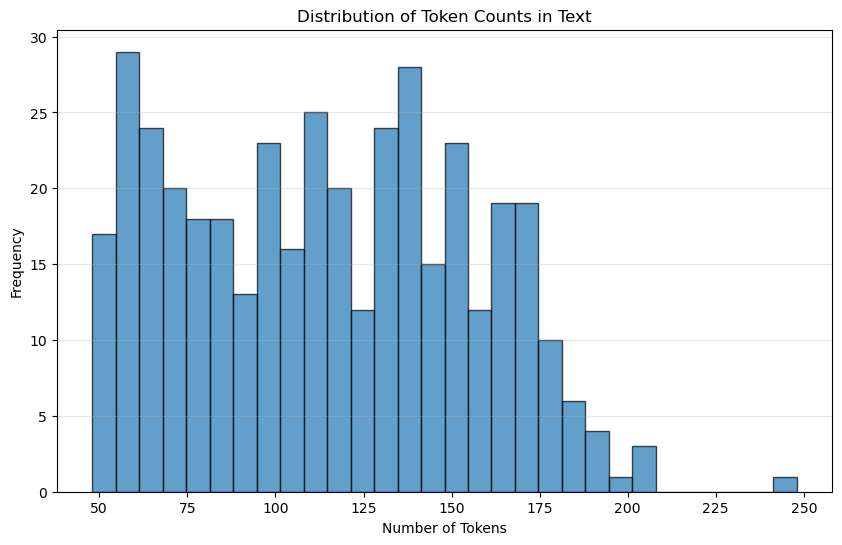

Mean: 114.61
Median: 114.00
Min: 48
Max: 248


In [5]:
import tiktoken
import matplotlib.pyplot as plt

# Initialize the tokenizer (using the encoding for GPT models)
encoding = tiktoken.encoding_for_model("gpt-4")

# Calculate token counts for each breakdown
p.data['token_count'] = p.data['text'].apply(
    lambda x: len(encoding.encode(str(x))) if pd.notna(x) else 0
)

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(p.data['token_count'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.title('Distribution of Token Counts in Text')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Display summary statistics
print(f"Mean: {p.data['token_count'].mean():.2f}")
print(f"Median: {p.data['token_count'].median():.2f}")
print(f"Min: {p.data['token_count'].min()}")
print(f"Max: {p.data['token_count'].max()}")

In [6]:
import torch

# Clear MPS cache
torch.mps.empty_cache()

model = RewardModel(Pairadigm=p)
model.model.to(model.device)

Model using device: mps


Module(
  (encoder): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 1024, padding_idx=50283)
      (norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=1024, out_features=3072, bias=False)
          (rotary_emb): ModernBertRotaryEmbedding()
          (Wo): Linear(in_features=1024, out_features=1024, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=1024, out_features=5248, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=2624, out_features=1024, bias=False)
        )
      )
      (1-27): 27 

In [8]:
original_text = p.data[[p.item_id_name, p.text_name]].copy()

prepped_data = pd.merge(
    prepped_data, original_text,
    left_on='item1',
    right_on=p.item_id_name,
    how='left').rename(columns={p.text_name: 'text1'}).drop(columns=[p.item_id_name]).merge(
        original_text,
        left_on='item2',
        right_on=p.item_id_name,
        how='left'
        ).rename(columns={p.text_name: 'text2'}).drop(columns=[p.item_id_name])

prepped_data

,item1,item2,breakdown1,breakdown2,decision,item_A_score,item_B_score,margin,text1,text2
0,17871506,6631034,Original Text: Card Name: Meteor Dragon Red-Ey...,Original Text: Card Name: Frostosaurus | Card...,Text1,0.819501,0.369738,-0.449763,Card Name: Meteor Dragon Red-Eyes Impact | Ca...,Card Name: Frostosaurus | Card Type: Normal M...
1,16024176,4042268,Original Text: Card Name: Flower Cardian Pine ...,Original Text: Card Name: Island Turtle | Car...,Text1,0.649560,0.378005,-0.271555,Card Name: Flower Cardian Pine with Crane | C...,Card Name: Island Turtle | Card Type: Normal ...
2,55888045,84653834,Original Text: Card Name: Number C106: Giant R...,Original Text: Card Name: ESP Amplifier | Car...,Text2,0.349030,0.428993,0.079964,Card Name: Number C106: Giant Red Hand | Card...,Card Name: ESP Amplifier | Card Type: Quick-P...
3,58116537,5758500,Original Text: Card Name: Ancient Warriors Sag...,Original Text: Card Name: Soul Release | Card...,Text1,0.490162,0.263342,-0.226820,Card Name: Ancient Warriors Saga - Sun-Liu All...,Card Name: Soul Release | Card Type: Normal S...
4,60303688,4042268,"Original Text: Card Name: Dogmatika Ecclesia, ...",Original Text: Card Name: Island Turtle | Car...,Text1,1.000000,0.378005,-0.621995,"Card Name: Dogmatika Ecclesia, the Virtuous | ...",Card Name: Island Turtle | Card Type: Normal ...
...,...,...,...,...,...,...,...,...,...,...
2741,77449773,8414337,Original Text: Card Name: Cynet Crosswipe | C...,Original Text: Card Name: Dust Storm of Gusto ...,Text1,0.543071,0.429611,-0.113460,Card Name: Cynet Crosswipe | Card Type: Quick...,Card Name: Dust Storm of Gusto | Card Type: N...
2742,65646587,88204302,Original Text: Card Name: Pendulum Fusion | C...,Original Text: Card Name: Speed Recovery | Ca...,Text1,0.603704,0.671302,0.067598,Card Name: Pendulum Fusion | Card Type: Norma...,Card Name: Speed Recovery | Card Type: Normal...
2743,65646587,25165047,Original Text: Card Name: Pendulum Fusion | C...,Original Text: Card Name: Life Stream Dragon |...,Text1,0.603704,0.406595,-0.197110,Card Name: Pendulum Fusion | Card Type: Norma...,Card Name: Life Stream Dragon | Card Type: Sy...
2744,59069885,38180759,Original Text: Card Name: Embrace of the Tisti...,Original Text: Card Name: Unformed Void | Car...,Text1,0.596589,0.374741,-0.221848,Card Name: Embrace of the Tistina | Card Type...,Card Name: Unformed Void | Card Type: Xyz Eff...


In [9]:
# Make a tuple of breakdown1, breakdown2, margin for each row in prepped_data
training_data = list(zip(
    prepped_data['text1'],
    prepped_data['text2'],
    prepped_data['margin']
))

dataloaders = model.prepare_data(training_data, test_size=0.1, eval_size=0.1, batch_size=4)

# Access the loaders
train_loader = dataloaders['train']
eval_loader = dataloaders['eval']
test_loader = dataloaders['test']

Data split - Train: 2196, Eval: 275, Test: 275


In [10]:
train_loader

In [11]:
model.train(train_loader, eval_loader, epochs=10, learning_rate=2e-5)

Epoch 1/10: 100%|██████████| 549/549 [53:29<00:00,  5.85s/it, loss=0.6513]  


Epoch 1 - Train Loss: 0.6551
Epoch 1 - Eval Loss: 0.6924, Eval Accuracy: 0.6255


Epoch 2/10: 100%|██████████| 549/549 [25:23<00:00,  2.77s/it, loss=0.6500]  


Epoch 2 - Train Loss: 0.6380
Epoch 2 - Eval Loss: 0.5321, Eval Accuracy: 0.7127


Epoch 3/10: 100%|██████████| 549/549 [21:32<00:00,  2.35s/it, loss=0.4408] 


...

Epoch 8 - Train Loss: 0.1359
Epoch 8 - Eval Loss: 0.2932, Eval Accuracy: 0.8618


Epoch 9/10: 100%|██████████| 549/549 [23:58<00:00,  2.62s/it, loss=0.1052]


Epoch 9 - Train Loss: 0.1073
Epoch 9 - Eval Loss: 0.3242, Eval Accuracy: 0.8618


Epoch 10/10: 100%|██████████| 549/549 [26:42<00:00,  2.92s/it, loss=0.0780]  


Epoch 10 - Train Loss: 0.0793
Epoch 10 - Eval Loss: 0.3351, Eval Accuracy: 0.8545


In [ ]:
model.save('../Results/starter_reward_model')

Model saved to ../Results/starter_reward_model_v3 (no good)


In [16]:
model.training_history

[{'epoch': 1,
  'train_loss': 0.5097104052288665,
  'eval_loss': 0.44137028669533523,
  'eval_accuracy': 0.7672727272727272},
 {'epoch': 2,
  'train_loss': 0.34830602933949567,
  'eval_loss': 0.38602647733321227,
  'eval_accuracy': 0.8109090909090909},
 {'epoch': 3,
  'train_loss': 0.25747190923463953,
  'eval_loss': 0.3254975637098761,
  'eval_accuracy': 0.8581818181818182},
 {'epoch': 4,
  'train_loss': 0.19529710067195952,
  'eval_loss': 0.2953891661617082,
  'eval_accuracy': 0.850909090909091},
 {'epoch': 5,
  'train_loss': 0.1394632030633495,
  'eval_loss': 0.28956385538546875,
  'eval_accuracy': 0.8545454545454545}]